In [1]:
!pip install transformers tokenizers lightning tensorboard


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.9/818.9 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Download pretrained CEFR classification model and train/dev/test datasets



In [2]:
# Create the directory
!mkdir -p pretrained

# Download the model into it
!wget -O pretrained/level_estimator.ckpt https://zenodo.org/records/7234096/files/level_estimator.ckpt?download=1


--2025-04-14 00:11:15--  https://zenodo.org/records/7234096/files/level_estimator.ckpt?download=1
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.48.194, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1238557141 (1.2G) [application/octet-stream]
Saving to: ‘pretrained/level_estimator.ckpt’

pretrained/level_es 100%[===================>]   1.15G  17.8MB/s    in 70s     

2025-04-14 00:12:25 (17.0 MB/s) - ‘pretrained/level_estimator.ckpt’ saved [1238557141/1238557141]



In [3]:
!mkdir -p dataset

!wget -O dataset/data_train.txt https://my-shared-downloads.s3.us-east-1.amazonaws.com/CEFR-SP_Wikiauto_train.txt
!wget -O dataset/data_dev.txt https://my-shared-downloads.s3.us-east-1.amazonaws.com/CEFR-SP_Wikiauto_dev.txt
!wget -O dataset/data_test.txt https://my-shared-downloads.s3.us-east-1.amazonaws.com/CEFR-SP_Wikiauto_test.txt

!mkdir -p out

--2025-04-14 00:12:35--  https://my-shared-downloads.s3.us-east-1.amazonaws.com/CEFR-SP_Wikiauto_train.txt
Resolving my-shared-downloads.s3.us-east-1.amazonaws.com (my-shared-downloads.s3.us-east-1.amazonaws.com)... 3.5.2.70, 16.182.105.218, 16.182.101.106, ...
Connecting to my-shared-downloads.s3.us-east-1.amazonaws.com (my-shared-downloads.s3.us-east-1.amazonaws.com)|3.5.2.70|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 565805 (553K) [text/plain]
Saving to: ‘dataset/data_train.txt’

dataset/data_train. 100%[===================>] 552.54K   634KB/s    in 0.9s    

2025-04-14 00:12:37 (634 KB/s) - ‘dataset/data_train.txt’ saved [565805/565805]

--2025-04-14 00:12:37--  https://my-shared-downloads.s3.us-east-1.amazonaws.com/CEFR-SP_Wikiauto_dev.txt
Resolving my-shared-downloads.s3.us-east-1.amazonaws.com (my-shared-downloads.s3.us-east-1.amazonaws.com)... 16.182.35.18, 54.231.195.234, 52.217.202.106, ...
Connecting to my-shared-downloads.s3.us-east-1.amazonaw

In [4]:
# Manual port of the code found in
# to be Notebook based https://github.com/yukiar/CEFR-SP

import random

import tqdm
import torch, glob, os, argparse
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
import numpy as np

import torch, scipy, transformers
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score

import torch, random, itertools, tqdm
import numpy as np
from torch import nn
from torch.utils.data import DataLoader

##Utility functions from src/util.py

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
        self.data_len=len(encodings['input_ids'])

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        return item

    def __len__(self):
        return self.data_len

class CEFRDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, sent_levels_a, sent_levels_b):
        self.encodings = encodings
        self.slabels_low = np.minimum(sent_levels_a, sent_levels_b)
        self.slabels_high = np.maximum(sent_levels_a, sent_levels_b)

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['slabels_low'] = self.slabels_low[idx].clone().detach()
        item['slabels_high'] = self.slabels_high[idx].clone().detach()
        return item

    def __len__(self):
        return len(self.slabels_high)


class ConcatDataset(torch.utils.data.Dataset):
    def __init__(self, *datasets):
        self.datasets = datasets

    def __getitem__(self, i):
        return tuple(d[i] for d in self.datasets)

    def __len__(self):
        return min(len(d) for d in self.datasets)


def read_corpus(path, num_labels):
    levels_a, levels_b, sents = [], [], []
    with open(path) as f:
        for line in f:
            array = line.strip().split('\t')
            sents.append(array[0].split(' '))
            levels_a.append(float(array[1]) - 1)  # Convert 1-6 to 0-5
            levels_b.append(float(array[2]) - 1)  # Convert 1-6 to 0-5

    levels_a = np.array(levels_a)
    levels_b = np.array(levels_b)

    return levels_a, levels_b, sents


def convert_numeral_to_six_levels(levels):
    level_thresholds = np.array([0.0, 0.5, 1.5, 2.5, 3.5, 4.5])
    return _conversion(level_thresholds, levels)


def _conversion(level_thresholds, values):
    thresh_array = np.tile(level_thresholds, reps=(values.shape[0], 1))
    array = np.tile(values, reps=(1, level_thresholds.shape[0]))
    levels = np.maximum(np.zeros((values.shape[0], 1)),
                        np.count_nonzero(thresh_array <= array, axis=1, keepdims=True) - 1).astype(int)
    return levels


# Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(token_embeddings, attention_mask):
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)


# Take attention mask into account for excluding padding
def token_embeddings_filtering_padding(token_embeddings, attention_mask):
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return token_embeddings * input_mask_expanded


def eval_multiclass(out_path, labels, predictions):
    cm = confusion_matrix(labels, predictions)
    plt.figure()
    sns.heatmap(cm)
    plt.savefig(out_path + '_confusion_matrix.png')

    report = classification_report(labels, predictions, digits=4)
    print(report)
    with open(out_path + '_test_report.txt', 'w') as fw:
        fw.write('{0}\n'.format(report))


def mean_confidence_interval(data, confidence=0.95):
    if len(data) > 5:
        data.remove(max(data))
        data.remove(min(data))
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n - 1)
    return m, h

# From src/model_base.py

class LevelEstimaterBase(pl.LightningModule):
    def __init__(self, corpus_path, test_corpus_path, pretrained_model, with_ib, attach_wlv,
                 num_labels,
                 word_num_labels, alpha,
                 batch_size,
                 learning_rate, warmup,
                 lm_layer):
        super().__init__()
        self.save_hyperparameters()
        self.CEFR_lvs = 6

        if attach_wlv and with_ib:
            raise Exception('Information bottleneck and word labels cannot be used together!')

        self.corpus_path = corpus_path
        self.test_corpus_path = test_corpus_path
        self.pretrained_model = pretrained_model
        self.with_ib = with_ib
        self.attach_wlv = attach_wlv
        self.num_labels = num_labels
        self.word_num_labels = word_num_labels
        self.alpha = alpha
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.warmup = warmup
        self.lm_layer = lm_layer
        self.test_outputs = []

        # Load pre-trained model
        self.load_pretrained_lm()

    def load_pretrained_lm(self):
        if 'roberta' in self.pretrained_model:
            self.tokenizer = AutoTokenizer.from_pretrained(self.pretrained_model, add_prefix_space=True)
        else:
            self.tokenizer = AutoTokenizer.from_pretrained(self.pretrained_model)
        self.lm = AutoModel.from_pretrained(self.pretrained_model)

    def precompute_loss_weights(self, epsilon=1e-5):
        train_levels_a, train_levels_b, _ = read_corpus(self.corpus_path + '_train.txt', self.num_labels)
        train_levels = np.concatenate((train_levels_a, train_levels_b[train_levels_b != train_levels_a]))

        train_sentlv_ratio = np.array([np.sum(train_levels == lv) for lv in range(self.CEFR_lvs)])
        train_sentlv_ratio = train_sentlv_ratio / np.sum(train_sentlv_ratio)
        train_sentlv_weights = np.power(train_sentlv_ratio, self.alpha) / np.sum(
            np.power(train_sentlv_ratio, self.alpha)) / (train_sentlv_ratio + epsilon)

        return torch.Tensor(train_sentlv_weights)

    def encode(self, batch):
        outputs = self.lm(batch['input_ids'], attention_mask=batch['attention_mask'], output_hidden_states=True)
        return outputs.hidden_states[self.lm_layer], None

    def forward(self, inputs):
        pass

    def training_step(self, batch, batch_idx):
        pass

    def validation_step(self, batch, batch_idx):
        pass

    def test_step(self, batch, batch_idx):
        logs, golds_predictions = self._shared_eval_step(batch)
        self.test_outputs.append(golds_predictions)  # Store predictions
        self.log_dict({f"test_{k}": v for k, v in logs.items()})
        return golds_predictions

    def on_test_epoch_end(self):
        logs = self.evaluation(self.test_outputs, test=True)
        self.log_dict({f"test_{k}": v for k, v in logs.items()}, prog_bar=True)
        self.test_outputs.clear()  # Clear for safety


    def get_gold_labels(self, predictions, lower_labels, higher_labels):
        if torch.sum(predictions == lower_labels) >= torch.sum(predictions == higher_labels):
            gold_labels = lower_labels
            gold_labels[predictions == higher_labels] = higher_labels[predictions == higher_labels]
        else:
            gold_labels = higher_labels
            gold_labels[predictions == lower_labels] = lower_labels[predictions == lower_labels]
        return gold_labels

    def evaluation(self, outputs, test=False):
        pred_labels, gold_labels_low, gold_labels_high = [], [], []
        for output in outputs:
            gold_labels_low += output['gold_labels_low'].tolist()
            gold_labels_high += output['gold_labels_high'].tolist()
            pred_labels += output['pred_labels'].tolist()

        gold_labels_high = np.array(gold_labels_high)
        gold_labels_low = np.array(gold_labels_low)
        pred_labels = np.array(pred_labels)

        # pick higher or lower labels that the model performs better
        gold_labels = self.get_gold_labels(torch.from_numpy(pred_labels), torch.from_numpy(gold_labels_low),
                                          torch.from_numpy(gold_labels_high))
        gold_labels = gold_labels.numpy()

        eval_f1 = f1_score(gold_labels, pred_labels, average='macro')
        accuracy = np.mean(pred_labels.flatten() == gold_labels.flatten())

        logs = {
            "f1_score": eval_f1,
            "accuracy": accuracy
        }

        if test:
            eval_multiclass(self.logger.log_dir + '/sentence', gold_labels, pred_labels)
            with open(self.logger.log_dir + '/test_predictions.txt', 'w') as fw:
                fw.write('Sentence_Lv\n')
                for sent_lv in pred_labels:
                    fw.write('{0}\n'.format(sent_lv))

        return logs


    def configure_optimizers(self):
        optimizer = transformers.AdamW(self.parameters(), lr=self.learning_rate)
        # Warm-up scheduler
        if self.warmup > 0:
            scheduler = transformers.get_constant_schedule_with_warmup(optimizer, num_warmup_steps=self.warmup)
            return {"optimizer": optimizer, "lr_scheduler": scheduler}
        else:
            return optimizer

    def prepare_data(self):
        self.train_levels_a, self.train_levels_b, self.train_sents = read_corpus(
            self.corpus_path + '_train.txt', self.num_labels)
        self.dev_levels_a, self.dev_levels_b, self.dev_sents = read_corpus(
            self.corpus_path + '_dev.txt', self.num_labels)
        self.test_levels_a, self.test_levels_b, self.test_sents = read_corpus(
            self.test_corpus_path + '_test.txt', self.num_labels)

    # return the dataloader for each split
    def train_dataloader(self):
        data_type = torch.float if self.num_labels == 1 else torch.long
        y_sent_a = torch.tensor(self.train_levels_a, dtype=data_type).unsqueeze(1)
        y_sent_b = torch.tensor(self.train_levels_b, dtype=data_type).unsqueeze(1)
        inputs = self.my_tokenize(self.train_sents)

        return DataLoader(CEFRDataset(inputs, y_sent_a, y_sent_b), batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        data_type = torch.float if self.num_labels == 1 else torch.long
        y_sent_a = torch.tensor(self.dev_levels_a, dtype=data_type).unsqueeze(1)
        y_sent_b = torch.tensor(self.dev_levels_b, dtype=data_type).unsqueeze(1)
        inputs = self.my_tokenize(self.dev_sents)

        return DataLoader(CEFRDataset(inputs, y_sent_a, y_sent_b), batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        data_type = torch.float if self.num_labels == 1 else torch.long
        y_sent_a = torch.tensor(self.test_levels_a, dtype=data_type).unsqueeze(1)
        y_sent_b = torch.tensor(self.test_levels_b, dtype=data_type).unsqueeze(1)
        inputs = self.my_tokenize(self.test_sents)

        return DataLoader(CEFRDataset(inputs, y_sent_a, y_sent_b), batch_size=self.batch_size, shuffle=False)

    def my_tokenize(self, sents):
        inputs = self.tokenizer(sents, return_tensors="pt", padding=True, is_split_into_words=True,
                                return_offsets_mapping=True)
        return inputs

    def retokenize_with_wordlvs(self, sents, wlvs):
        wlv_sequences = [[self.word_lv_dic[lv] for lv in wlv_list if lv >= 0 and lv < self.word_num_labels] for wlv_list
                         in
                         wlvs.clone().detach().numpy()]
        inputs = self.tokenizer(sents, text_pair=wlv_sequences, return_tensors="pt", padding=True,
                                is_split_into_words=True,
                                return_offsets_mapping=True)
        return inputs

    def wordlabel_to_tokenlabel(self, all_token_ids, all_offsets_mapping, labels):
        token_labels = torch.zeros_like(all_token_ids)
        for sid in range(all_token_ids.shape[0]):
            wid = -1
            for i, offset in enumerate(all_offsets_mapping[sid]):
                if offset[1] == 0:  # Special tokens like CLS, PAD # Faster but cannot handle self-added [SEP] token
                # if all_token_ids[sid][i] in self.tokenizer.all_special_ids: # Special tokens like CLS, PAD: Much slower
                    token_labels[sid, i] = -1
                    continue
                if offset[0] == 0:  # New word starts
                    wid += 1
                token_labels[sid, i] = labels[sid][wid]
        return token_labels

# from src/model.py


class LevelEstimaterClassification(LevelEstimaterBase):
    def __init__(self, corpus_path, test_corpus_path, pretrained_model, problem_type, with_ib, with_loss_weight,
                 attach_wlv, num_labels,
                 word_num_labels, alpha,
                 ib_beta,
                 batch_size,
                 learning_rate,
                 warmup,
                 lm_layer):
        super().__init__(corpus_path, test_corpus_path, pretrained_model, with_ib, attach_wlv, num_labels,
                         word_num_labels, alpha,
                         batch_size,
                         learning_rate, warmup, lm_layer)
        self.save_hyperparameters()

        self.problem_type = problem_type
        self.with_loss_weight = with_loss_weight
        self.ib_beta = ib_beta
        self.dropout = nn.Dropout(0.1)

        if self.problem_type == "regression":
            self.slv_classifier = nn.Linear(self.lm.config.hidden_size, 1)
            self.loss_fct = nn.MSELoss()
        else:
            self.slv_classifier = nn.Linear(self.lm.config.hidden_size, self.CEFR_lvs)
            if self.with_loss_weight:
                train_sentlv_weights = self.precompute_loss_weights()
                self.loss_fct = nn.CrossEntropyLoss(weight=train_sentlv_weights)
            else:
                self.loss_fct = nn.CrossEntropyLoss()

    def forward(self, inputs):
        # in lightning, forward defines the prediction/inference actions
        outputs, information_loss = self.encode(inputs)
        outputs = mean_pooling(outputs, attention_mask=inputs['attention_mask'])
        logits = self.slv_classifier(self.dropout(outputs))

        if self.problem_type == "regression":
            predictions = convert_numeral_to_six_levels(logits.detach().clone().cpu().numpy())
        else:
            predictions = torch.argmax(torch.softmax(logits.detach().clone(), dim=1), dim=1, keepdim=True)


        loss = None
        if 'slabels_high' in inputs:
            if self.problem_type == "regression":
                labels = (inputs['slabels_high'] + inputs['slabels_low']) / 2
                cls_loss = self.loss_fct(logits.squeeze(), labels.squeeze())
            else:
                labels = self.get_gold_labels(predictions, inputs['slabels_low'].detach().clone(),
                                              inputs['slabels_high'].detach().clone())
                cls_loss = self.loss_fct(logits.view(-1, self.CEFR_lvs), labels.view(-1))

            loss = cls_loss
            logs = {"loss": cls_loss}

        predictions = predictions.cpu().numpy()

        return (loss, predictions, logs) if loss is not None else predictions

    def step(self, batch):
        loss, predictions, logs = self.forward(batch)
        return loss, logs

    def _shared_eval_step(self, batch):
        loss, predictions, logs = self.forward(batch)

        gold_labels_low = batch['slabels_low'].cpu().detach().clone().numpy()
        gold_labels_high = batch['slabels_high'].cpu().detach().clone().numpy()
        golds_predictions = {'gold_labels_low': gold_labels_low, 'gold_labels_high': gold_labels_high,
                             'pred_labels': predictions}

        return logs, golds_predictions

    def training_step(self, batch, batch_idx):
        loss, logs = self.step(batch)
        self.log_dict({f"train_{k}": v for k, v in logs.items()})
        return loss

    def validation_step(self, batch, batch_idx):
        logs, golds_predictions = self._shared_eval_step(batch)
        self.log_dict({f"val_{k}": v for k, v in logs.items()})
        return golds_predictions

    def validation_epoch_end(self, outputs):
        logs = self.evaluation(outputs)
        self.log_dict({f"val_{k}": v for k, v in logs.items()})

    def test_step(self, batch, batch_idx):
        logs, golds_predictions = self._shared_eval_step(batch)
        self.log_dict({f"test_{k}": v for k, v in logs.items()})
        return golds_predictions

    def test_epoch_end(self, outputs):
        logs = self.evaluation(outputs, test=True)
        self.log_dict({f"test_{k}": v for k, v in logs.items()})


class LevelEstimaterContrastive(LevelEstimaterBase):
    def __init__(self, corpus_path, test_corpus_path, pretrained_model, problem_type, with_ib, with_loss_weight,
                 attach_wlv, num_labels,
                 word_num_labels,
                 num_prototypes,
                 alpha,
                 ib_beta,
                 batch_size,
                 learning_rate,
                 warmup,
                 lm_layer):
        super().__init__(corpus_path, test_corpus_path, pretrained_model, with_ib, attach_wlv, num_labels,
                         word_num_labels, alpha,
                         batch_size,
                         learning_rate, warmup, lm_layer)
        self.save_hyperparameters()

        self.problem_type = problem_type
        self.num_prototypes = num_prototypes
        self.with_loss_weight = with_loss_weight
        self.ib_beta = ib_beta

        self.prototype = nn.Embedding(self.CEFR_lvs * self.num_prototypes, self.lm.config.hidden_size)
        # nn.init.xavier_normal_(self.prototype.weight)  # Xavier initialization
        # nn.init.orthogonal_(self.prototype.weight)  # Make prototype vectors orthogonal

        if self.with_loss_weight:
            loss_weights = self.precompute_loss_weights()
            self.loss_fct = nn.CrossEntropyLoss(weight=loss_weights)
        else:
            self.loss_fct = nn.CrossEntropyLoss()

    def forward(self, batch):
        # in lightning, forward defines the prediction/inference actions
        outputs, information_loss = self.encode(batch)
        outputs = mean_pooling(outputs, attention_mask=batch['attention_mask'])

        # positive: compute cosine similarity
        outputs = torch.nn.functional.normalize(outputs)
        positive_prototypes = torch.nn.functional.normalize(self.prototype.weight)
        logits = torch.mm(outputs, positive_prototypes.T)
        logits = logits.reshape((-1, self.num_prototypes, self.CEFR_lvs))
        logits = logits.mean(dim=1)

        # prediction
        predictions = torch.argmax(torch.softmax(logits.detach().clone(), dim=1), dim=1, keepdim=True)

        loss = None
        if 'slabels_high' in batch:
            labels = self.get_gold_labels(predictions, batch['slabels_low'].detach().clone(),
                                          batch['slabels_high'].detach().clone())
            # cross-entropy loss
            cls_loss = self.loss_fct(logits.view(-1, self.CEFR_lvs), labels.view(-1))

            loss = cls_loss
            logs = {"loss": loss}

        predictions = predictions.cpu().numpy()

        return (loss, predictions, logs) if loss is not None else predictions

    def _shared_eval_step(self, batch):
        loss, predictions, logs = self.forward(batch)

        gold_labels_low = batch['slabels_low'].cpu().detach().clone().numpy()
        gold_labels_high = batch['slabels_high'].cpu().detach().clone().numpy()
        golds_predictions = {'gold_labels_low': gold_labels_low, 'gold_labels_high': gold_labels_high,
                             'pred_labels': predictions}

        return logs, golds_predictions

    def on_train_start(self) -> None:
        # Init with BERT embeddings
        epcilon = 1.0e-6
        higher_labels, lower_labels = [], []
        prototype_initials = torch.full((self.CEFR_lvs, self.lm.config.hidden_size), fill_value=epcilon).to(self.device)

        self.lm.eval()
        for batch in tqdm.tqdm(self.train_dataloader(), leave=False, desc='init prototypes'):
            higher_labels += batch['slabels_high'].squeeze().detach().clone().numpy().tolist()
            lower_labels += batch['slabels_low'].squeeze().detach().clone().numpy().tolist()
            batch = {k: v.cuda() for k, v in batch.items()}
            with torch.no_grad():
                outputs = self.lm(batch['input_ids'], attention_mask=batch['attention_mask'], output_hidden_states=True)
                outputs_mean = mean_pooling(outputs.hidden_states[self.lm_layer],
                                            attention_mask=batch['attention_mask'])
            for lv in range(self.CEFR_lvs):
                prototype_initials[lv] += outputs_mean[
                    (batch['slabels_low'].squeeze() == lv) | (batch['slabels_high'].squeeze() == lv)].sum(0)
        if not self.with_ib:
            self.lm.train()

        higher_labels = torch.tensor(higher_labels)
        lower_labels = torch.tensor(lower_labels)
        for lv in range(self.CEFR_lvs):
            denom = torch.count_nonzero((higher_labels == lv) | (lower_labels == lv)) + epcilon
            prototype_initials[lv] = prototype_initials[lv] / denom

        var = torch.var(prototype_initials).item() * 0.05 # Add Gaussian noize with 5% variance of the original tensor
        # prototype_initials = torch.repeat_interleave(prototype_initials, self.num_prototypes, dim=0)
        prototype_initials = prototype_initials.repeat(self.num_prototypes, 1)
        noise = (var ** 0.5) * torch.randn(prototype_initials.size()).to(self.device)
        prototype_initials = prototype_initials + noise  # Add Gaussian noize
        self.prototype.weight = nn.Parameter(prototype_initials)
        nn.init.orthogonal_(self.prototype.weight)  # Make prototype vectors orthogonal

        # # Init with Xavier
        # nn.init.xavier_normal_(self.prototype.weight)  # Xavier initialization

    def training_step(self, batch, batch_idx):
        loss, predictions, logs = self.forward(batch)
        self.log_dict({f"train_{k}": v for k, v in logs.items()})
        return loss

    def validation_step(self, batch, batch_idx):
        logs, golds_predictions = self._shared_eval_step(batch)
        self.log_dict({f"val_{k}": v for k, v in logs.items()})
        return golds_predictions

    def validation_epoch_end(self, outputs):
        logs = self.evaluation(outputs)
        self.log_dict({f"val_{k}": v for k, v in logs.items()})

    def test_step(self, batch, batch_idx):
        logs, golds_predictions = self._shared_eval_step(batch)
        #print(f"Test step {batch_idx}: preds = {golds_predictions['pred_labels']}")
        self.test_outputs.append(golds_predictions)
        self.log_dict({f"test_{k}": v for k, v in logs.items()})
        return golds_predictions



# From src/baseline.py



class BaselineClassification(LevelEstimaterBase):
    def __init__(self, corpus_path, test_corpus_path, pretrained_model, problem_type, attach_wlv, num_labels,
                 word_num_labels, alpha,
                 batch_size,
                 learning_rate,
                 warmup,
                 lm_layer):
        super().__init__(corpus_path, test_corpus_path, pretrained_model, False, attach_wlv, num_labels,
                         word_num_labels, alpha,
                         batch_size,
                         learning_rate, warmup, lm_layer)
        self.save_hyperparameters()

        self.problem_type = problem_type
        self.dropout = nn.Dropout(0.1)

        if self.problem_type == 'baseline_reg':
            self.slv_classifier = nn.Linear(self.lm.config.hidden_size, 1)
            self.loss_fct = nn.MSELoss()
        else:
            self.slv_classifier = nn.Linear(self.lm.config.hidden_size, self.num_labels)
            self.loss_fct = nn.CrossEntropyLoss()

    def forward(self, inputs):
        # in lightning, forward defines the prediction/inference actions
        outputs, _ = self.encode(inputs)
        outputs_mean = mean_pooling(outputs, attention_mask=inputs['attention_mask'])
        logits = self.slv_classifier(self.dropout(outputs_mean))

        loss = None
        if inputs['slabels_high'] is not None:
            if self.problem_type == 'baseline_reg':
                labels = (inputs['slabels_high'] + inputs['slabels_low']) / 2
                loss = self.loss_fct(logits.squeeze(), labels.squeeze())
            else:
                labels = self.get_gold_labels(inputs['slabels_low'].detach().clone(), inputs['slabels_high'].detach().clone())
                loss = self.loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            logs = {"loss": loss}

        if self.problem_type == "regression":
            predictions = convert_numeral_to_six_levels(logits.cpu().detach().clone().numpy())
        else:
            predictions = torch.argmax(torch.softmax(logits.detach().clone(), dim=1), dim=1, keepdim=True).cpu().numpy()

        return (loss, predictions, logs) if loss is not None else predictions

    def step(self, batch):
        loss, predictions, logs = self.forward(batch)
        return loss, logs

    def _shared_eval_step(self, batch):
        loss, predictions, logs = self.forward(batch)

        gold_labels_low = batch['slabels_low'].cpu().detach().clone().numpy()
        gold_labels_high = batch['slabels_high'].cpu().detach().clone().numpy()
        golds_predictions = {'gold_labels_low': gold_labels_low, 'gold_labels_high': gold_labels_high,
                             'pred_labels': predictions}

        return logs, golds_predictions

    def training_step(self, batch, batch_idx):
        loss, logs = self.step(batch)
        self.log_dict({f"train_{k}": v for k, v in logs.items()})
        return loss

    def validation_step(self, batch, batch_idx):
        logs, golds_predictions = self._shared_eval_step(batch)
        self.log_dict({f"val_{k}": v for k, v in logs.items()})
        return golds_predictions

    def validation_epoch_end(self, outputs):
        logs = self.evaluation(outputs)
        self.log_dict({f"val_{k}": v for k, v in logs.items()})

    def test_step(self, batch, batch_idx):
        logs, golds_predictions = self._shared_eval_step(batch)
        self.log_dict({f"test_{k}": v for k, v in logs.items()})
        return golds_predictions

    def test_epoch_end(self, outputs):
        logs = self.evaluation(outputs, test=True)
        self.log_dict({f"test_{k}": v for k, v in logs.items()})


## Perform test using pretrained model

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.5.10 to v2.5.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint pretrained/level_estimator.ckpt`
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

...

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['lm.embeddings.position_ids']
INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:p

Testing: |          | 0/? [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     1.0000    0.2500    0.4000         4
           1     0.6471    0.8800    0.7458        25
           2     0.8707    0.9197    0.8945       249
           3     0.9272    0.8669    0.8960       323
           4     0.8811    0.9065    0.8936       139
           5     1.0000    0.8636    0.9268        22

    accuracy                         0.8885       762
   macro avg     0.8877    0.7811    0.7928       762
weighted avg     0.8936    0.8885    0.8884       762



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8884514570236206     │
│       test_f1_score       │    0.7927900552749634     │
│         test_loss         │    1.3854261636734009     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.3854261636734009,
  'test_f1_score': 0.7927900552749634,
  'test_accuracy': 0.8884514570236206}]

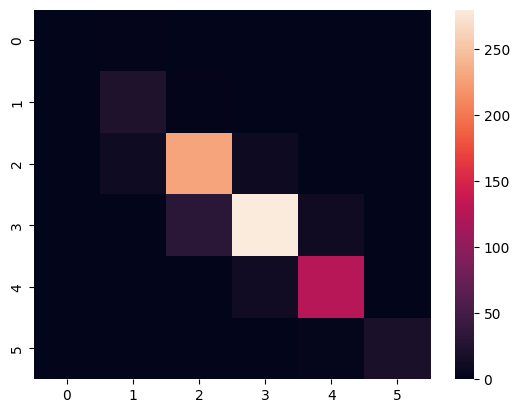

In [5]:


gpus = torch.cuda.device_count()

args = {
    'model': 'bert-base-cased',
    'lm_layer': 11,
    'seed': 935,
    'num_labels': 6,
    'batch': 128,
    'warmup': 0,
    'with_loss_weight': True,
    'num_prototypes': 3,
    'type': 'contrastive',
    'init_lr': 1.0e-5,
    'alpha': 0.2,
    'data': './dataset/data',
    'test': './dataset/data',
    'out': './out/',
    'pretrained': './pretrained/level_estimator.ckpt',
    'val_check_interval': 1.0,
    'beta': 0.5,
    'ib_beta': 1e-5,
    'word_num_labels': 4,
    'with_ib': False,
    'attach_wlv': False
}

lv_estimater = LevelEstimaterContrastive.load_from_checkpoint(
    args['pretrained'],
    strict=False,
    corpus_path=args['data'],
    test_corpus_path=args['test'],
    pretrained_model=args['model'],
    with_ib=args['with_ib'],
    with_loss_weight=args['with_loss_weight'],
    attach_wlv=args['attach_wlv'],
    num_labels=args['num_labels'],
    word_num_labels=args['word_num_labels'],
    num_prototypes=args['num_prototypes'],
    alpha=args['alpha'],
    ib_beta=args['ib_beta'],
    batch_size=args['batch'],
    learning_rate=args['init_lr'],
    warmup=args['warmup'],
    lm_layer=args['lm_layer']
)

trainer = pl.Trainer()
lv_estimater.prepare_data()

# Feed the test data through lv_estimator, just to verify
# that we have loaded and built it correctly
trainer.test(lv_estimater)

In [27]:
# This allows us to use the model to classify an arbitrary collection of sentences
def predict_sentences(model, sentences: list):
    model.eval()
    inputs = model.tokenizer(
        sentences,
        return_tensors="pt",
        padding=True,
        is_split_into_words=False,
        return_offsets_mapping=True
    ).to(model.device)

    with torch.no_grad():
        pred_labels = model(inputs)
    return pred_labels.flatten().tolist()

sentences = [
    "Olfactory hallucinations can be caused by common medical conditions such as nasal infections , nasal polyps , or dental problems.",
    "She has been to the museum twice.",
    "Despite the weather, we went out anyway."

]

predictions = predict_sentences(lv_estimater, sentences)
print(predictions)


[4, 1, 1]


In [34]:
# Now we can just download the augmented train and test datasets, complete with
# the GPT-4 generated synthetic user prompts. (these were all created in the
# second notebook)
!mkdir -p augmented

!wget -O augmented/zero.jsonl https://my-shared-downloads.s3.us-east-1.amazonaws.com/zero.jsonl
!wget -O augmented/one.jsonl https://my-shared-downloads.s3.us-east-1.amazonaws.com/one.jsonl
!wget -O augmented/two.jsonl https://my-shared-downloads.s3.us-east-1.amazonaws.com/two.jsonl
!wget -O augmented/three.jsonl https://my-shared-downloads.s3.us-east-1.amazonaws.com/three.jsonl

!mkdir -p results

--2025-04-14 01:50:30--  https://my-shared-downloads.s3.us-east-1.amazonaws.com/zero.jsonl
Resolving my-shared-downloads.s3.us-east-1.amazonaws.com (my-shared-downloads.s3.us-east-1.amazonaws.com)... 54.231.129.58, 52.217.200.50, 54.231.225.138, ...
Connecting to my-shared-downloads.s3.us-east-1.amazonaws.com (my-shared-downloads.s3.us-east-1.amazonaws.com)|54.231.129.58|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 279864 (273K) [binary/octet-stream]
Saving to: ‘augmented/zero.jsonl’

augmented/zero.json 100%[===================>] 273.30K  77.3KB/s    in 3.5s    

2025-04-14 01:50:35 (77.3 KB/s) - ‘augmented/zero.jsonl’ saved [279864/279864]

--2025-04-14 01:50:35--  https://my-shared-downloads.s3.us-east-1.amazonaws.com/one.jsonl
Resolving my-shared-downloads.s3.us-east-1.amazonaws.com (my-shared-downloads.s3.us-east-1.amazonaws.com)... 52.217.225.114, 52.217.112.66, 54.231.228.250, ...
Connecting to my-shared-downloads.s3.us-east-1.amazonaws.com (my-share

In [9]:
import json

def load_dataset_from_jsonl(filepath):

    dataset = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            dataset.append(json.loads(line))
    return dataset

In [41]:
def prepare_for_test(entry):

    # remove the last entry of messages
    entry["messages"].pop()

    # add some guidance to ensure we get 1 sentence
    entry["messages"][0]["content"] = entry["messages"][0]["content"] + "\nTHE ASSISTANT RESPONSE MUST BE NO MORE THAN 1 SENTENCE"
    return entry


import openai
import os

os.environ['OPENAI_API_KEY'] = "redacted"

client = openai.OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Given a sentence - generate a synthetic user prompt that could have
# prompted a chatbot to produce it
def generate_test_response(entry, model):

    response = client.chat.completions.create(
        model=model,
        messages=entry["messages"]
    )

    return response.choices[0].message.content.strip()


import time
from typing import List, Dict

# parse out the A1, A2, B1 from the system prompt string:
# "You are a chat bot assistant which restricts your output language to CEFR level A2"
def get_intended_level(entry):
    return entry["messages"][0]["content"][80:82]


# Uses a GPT 4 model (vanilla or fine tuned) to generate the CEFR
# level compliant responses for an entire dataset, one already augmented
# with the synthetic prompts and possibly with n examples.
#
# A new key "test_response" will be added to each dict to capture what
# the model generated.
def generate_all_test_responses(dataset, model, delay: float = 0.1) -> None:

    for i, entry in enumerate(dataset):

        if i % 50 == 0:
            print(f"Generating response for item {i}")
        try:
            prepare_for_test(entry)
            response = generate_test_response(entry, model)
            entry["test_response"] = response
        except Exception as e:
            print(f"⚠️ Error generating response for item {i}: {e}")
            continue

        time.sleep(delay)

def score_dataset(dataset):

    # Do this is batches of 18, I don't know how high of a batch
    # size lv_estimator supports
    batch_size = 18
    all_predictions = []

    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i + batch_size]

        sentences = [entry["test_response"] for entry in batch]

        predictions = predict_sentences(lv_estimater, sentences)
        all_predictions.extend(predictions)

    # Now we have predicted the classes of all sentences, lets
    # calculate the overal "intended was classified correctly" accuracy
    # This will involve comparing the prediction from lv_estimator
    # to the intended level (which we can extract from the system message)
    level_map = {
        "A1": 1,
        "A2": 2,
        "B1": 3,
        "B2": 4,
        "C1": 5,
        "C2": 6
    }

    exactly_correct = 0
    almost_correct = 0

    for i, entry in enumerate(dataset):
        intended_level = level_map[get_intended_level(entry)]

        # the lv classifier is 0 based, so add 1 to it
        predicted_level = all_predictions[i] + 1

        # save the intended and predicted level integer values
        entry["predicted_level"] = predicted_level
        entry["intended_level"] = intended_level

        if intended_level == predicted_level:
            exactly_correct += 1
        if abs(intended_level - predicted_level) <= 1:
            almost_correct += 1

    exact_accuracy = exactly_correct / len(dataset)
    close_accuracy = almost_correct / len(dataset)

    return exact_accuracy, close_accuracy



def save_augmented_dataset_as_jsonl(dataset: List[Dict], filepath: str) -> None:
    """
    Saves the augmented dataset (list of dicts) to a JSONL file.

    Args:
        dataset (List[Dict]): The dataset to save.
        filepath (str): The path to the JSONL file to write.
    """
    with open(filepath, "w", encoding="utf-8") as f:
        for example in dataset:
            json.dump(example, f, ensure_ascii=False)
            f.write("\n")


In [42]:
# We use the fine tuned model with 0 examples, and the base GPT-4
# with 0, 1, 2 and 3 examples from each CEFR class.  This gives us
# five total test / dataset configurations that we need to generate
# assistant responses for and then use the pretrained CEFR classification model
# to classify the CEFR level.  We then compare that predicted CEFR level
# to the intended level and mark as correct if they match, finally calculating
# an overall "matched correctly" percentage across the dataset in each config.

configs = [
    {"name": "fine-tuned", "model": "ft:gpt-4o-mini-2024-07-18:simon-initiative-cmu::BLdTG9t0", "file_name": "zero.jsonl"},
    {"name": "zero-shot", "model": "gpt-4o-mini-2024-07-18", "file_name": "zero.jsonl"},
    {"name": "one-shot", "model": "gpt-4o-mini-2024-07-18", "file_name": "one.jsonl"},
    {"name": "two-shot", "model": "gpt-4o-mini-2024-07-18", "file_name": "two.jsonl"},
    {"name": "three-shot", "model": "gpt-4o-mini-2024-07-18", "file_name": "three.jsonl"}
]

def run_config_test(config):

    print(f"Running test for {config['name']}")

    # load the data set and generate responses for all entries
    file_name = config["file_name"]
    name = config["name"]

    dataset = load_dataset_from_jsonl(f"./augmented/{file_name}")

    generate_all_test_responses(dataset, config["model"])

    # now take all the generated reponses and pass them into the classifier
    # to calculate an overall exact and 'close' accuracy
    exact_accuracy, close_accuracy = score_dataset(dataset)

    config["exact_accuracy"] = exact_accuracy
    config["close_accuracy"] = close_accuracy

    print(f"Exact accuracy: {exact_accuracy}")
    print(f"Close accuracy: {close_accuracy}")

    # Save the results with the intended and predicted result and
    # the actual generated response.  We will need this for
    # further analysis
    save_augmented_dataset_as_jsonl(dataset, f"./results/{name}.jsonl")

    return config

[run_config_test(config) for config in configs]

print(results)



Running test for fine-tuned
Generating response for item 0
Generating response for item 50
Generating response for item 100
Generating response for item 150
Generating response for item 200
Generating response for item 250
Generating response for item 300
Generating response for item 350
Generating response for item 400
Generating response for item 450
Generating response for item 500
Generating response for item 550
Generating response for item 600
Generating response for item 650
Generating response for item 700
Generating response for item 750
Exact accuracy: 0.4566929133858268
Close accuracy: 0.9330708661417323
Running test for zero-shot
Generating response for item 0
Generating response for item 50
Generating response for item 100
Generating response for item 150
Generating response for item 200
Generating response for item 250
Generating response for item 300
Generating response for item 350
Generating response for item 400
Generating response for item 450
Generating response for

In [ ]:
print()